In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
import sympy
from sympy.physics.control.lti import TransferFunction
from sympy.physics.control.control_plots import pole_zero_plot
from sympy.physics.control.control_plots import bode_plot
from sympy.physics.control.control_plots import impulse_response_plot
from sympy.physics.control.control_plots import step_response_plot
from sympy.physics.control.control_plots import ramp_response_plot
from sympy.abc import x, y
t, s, x = sympy.symbols('t, s, x', positive=True)
a = sympy.symbols('a', real=True, positive=True)
sympy.init_printing()

plt.rcParams['font.size'] = 6

In [2]:
df = pd.read_csv("pwm_system_id.csv")
pwm = df["PWM"].to_numpy()
fl_angular = df["FL [rad/s]"].to_numpy()
fr_angular = df["FR [rad/s]"].to_numpy()
rr_angular = df["RR [rad/s]"].to_numpy()
rl_angular = df["RL [rad/s]"].to_numpy()

In [3]:
df.head()

,PWM,FL [rad/s],FL [m/s],FR [rad/s],FR [m/s],RR [rad/s],RR [m/s],RL [rad/s],RL [m/s]
0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,5.0,0.091992,0.018675,0.019920,0.004044,0.168652,0.034237,0.183984,0.037350
2,10.0,1.805660,0.366558,1.805660,0.366558,1.119238,0.227211,1.149902,0.233436
3,15.0,2.998050,0.608619,2.998050,0.608619,2.391971,0.485582,2.253809,0.457534
4,20.0,3.357715,0.681633,3.357715,0.681633,3.235059,0.656733,3.143066,0.638058


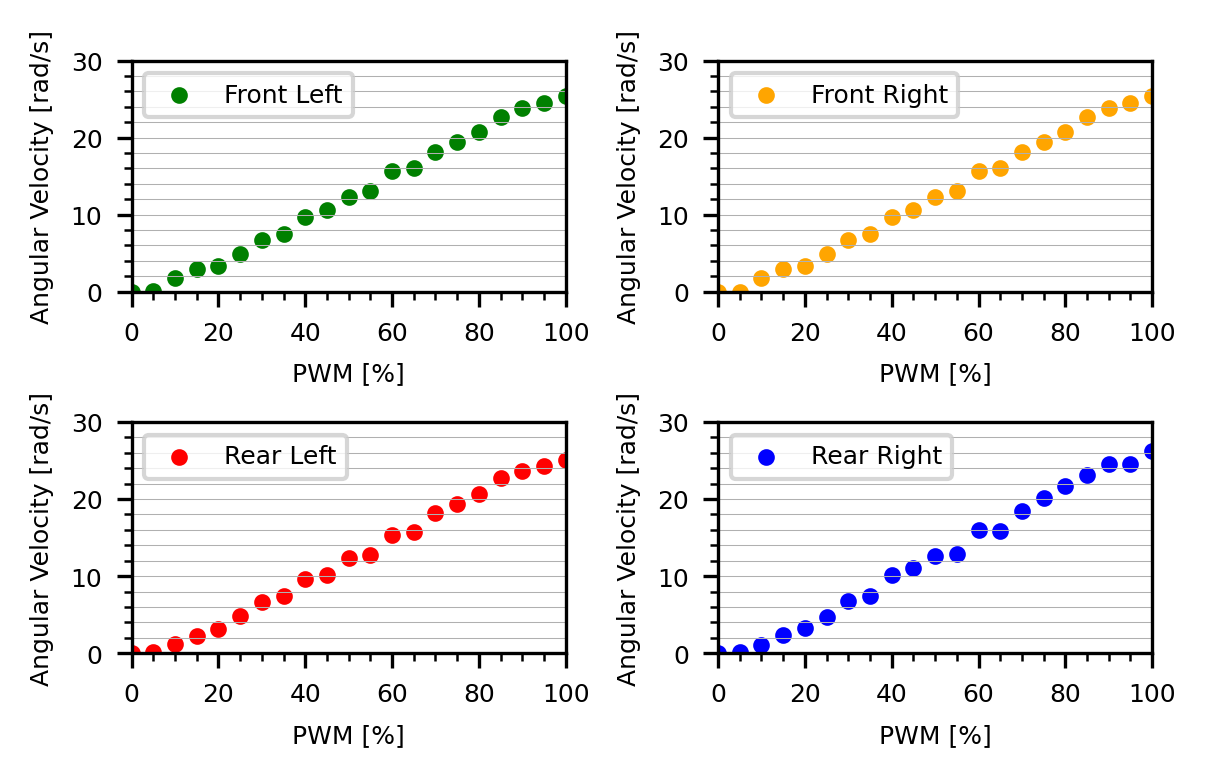

In [4]:
fig, axs = plt.subplots(2,2,figsize=[4,2.5], dpi=300)
for i, ax in enumerate(axs.flatten()):
    plt.axes(ax)
    plt.ylabel("Angular Velocity [rad/s]")
    plt.xlabel("PWM [%]")
    plt.grid(axis="y", linestyle="-", linewidth="0.25", which="both")
    plt.minorticks_on()
    plt.ylim([0,30])
    plt.xlim([0,100])

plt.axes(axs[0][0])
plt.scatter(pwm, fl_angular, marker=".", color="green", label="Front Left");

plt.axes(axs[0][1])
plt.scatter(pwm, fr_angular, marker=".", color="orange", label="Front Right");

plt.axes(axs[1][1])
plt.scatter(pwm, rr_angular, marker=".", color="blue", label="Rear Right");

plt.axes(axs[1][0])
plt.scatter(pwm, rl_angular, marker=".", color="red", label="Rear Left");


for i, ax in enumerate(axs.flatten()):
    plt.axes(ax)
    plt.legend()

plt.tight_layout()

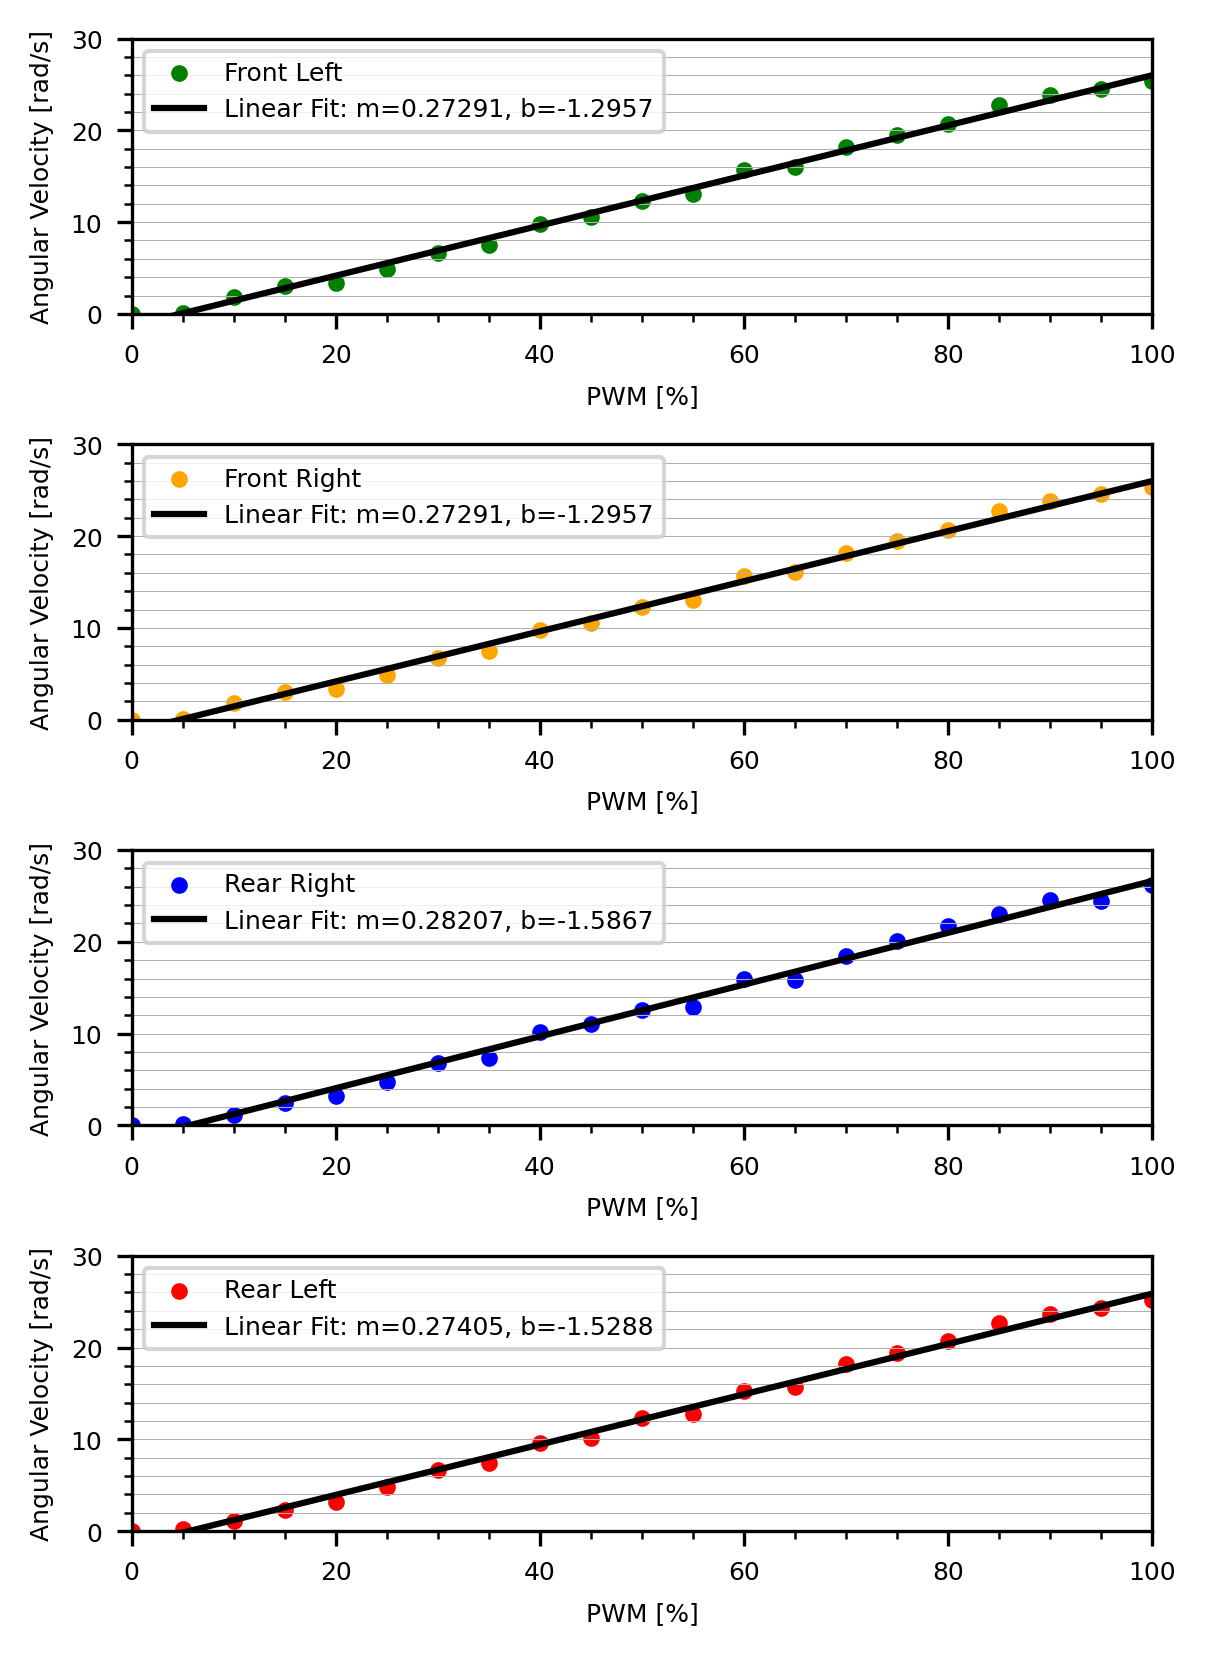

In [12]:
def linfit(x, m, b):
    return m*x + b

def poly3d(x, a, b, c, d):
    return a + b*x + c*x**2 + d*x**3

fig, axs = plt.subplots(4,1,figsize=[4,5.5], dpi=300)
for i, ax in enumerate(axs.flatten()):
    plt.axes(ax)
    plt.ylabel("Angular Velocity [rad/s]")
    plt.xlabel("PWM [%]")
    plt.grid(axis="y", linestyle="-", linewidth="0.25", which="both")
    plt.minorticks_on()
    plt.ylim([0,30])
    plt.xlim([0,100])

plt.axes(axs[0])
plt.scatter(pwm, fl_angular, marker=".", color="green", label="Front Left");
coeffs, _ = curve_fit(linfit, pwm, fl_angular)
D=coeffs[1]
C=coeffs[0]
plt.plot(pwm, linfit(pwm, *coeffs), color="black", label='Linear Fit: m=%7.5f, b=%6.4f' % (C, D))

plt.axes(axs[1])
plt.scatter(pwm, fr_angular, marker=".", color="orange", label="Front Right");
popt, pcov = curve_fit(linfit, pwm, fr_angular)
D=coeffs[1]
C=coeffs[0]
plt.plot(pwm, linfit(pwm, *coeffs), color="black", label='Linear Fit: m=%7.5f, b=%6.4f' % (C, D))

plt.axes(axs[2])
plt.scatter(pwm, rr_angular, marker=".", color="blue", label="Rear Right");
coeffs, _ = curve_fit(linfit, pwm, rr_angular)
D=coeffs[1]
C=coeffs[0]
plt.plot(pwm, linfit(pwm, *coeffs), color="black", label='Linear Fit: m=%7.5f, b=%6.4f' % (C, D))

plt.axes(axs[3])
plt.scatter(pwm, rl_angular, marker=".", color="red", label="Rear Left");
coeffs, _ = curve_fit(linfit, pwm, rl_angular)
D=coeffs[1]
C=coeffs[0]
plt.plot(pwm, linfit(pwm, *coeffs), color="black", label='Linear Fit: m=%7.5f, b=%6.4f' % (C, D))

for i, ax in enumerate(axs.flatten()):
    plt.axes(ax)
    plt.legend()

plt.tight_layout()

https://dynamics-and-control.readthedocs.io/en/latest/1_Dynamics/3_Linear_systems/Laplace%20transforms.html

In [16]:
def L(f):
    return sympy.laplace_transform(f, x, s, noconds=True)

def invL(F):
    return sympy.inverse_laplace_transform(F, s, t)

In [17]:
for wheel in [fl_angular, fr_angular, rr_angular, rl_angular
             ]:
    coeffs, _ = curve_fit(linfit, pwm, wheel)
    D = coeffs[1]
    C = coeffs[0]
    
    wheel_pwm_domain = (C*x + D)
    wheel_pwm_domain = wheel_pwm_domain
    print(C, D)

0.27291033895945316 -1.295702995675999
0.2730788189594534 -1.3075589956760272
0.28206923374321247 -1.5866751633510998
0.27404910467374133 -1.528822567105082
